# Assignment 2: CNN Image Classifier (Tiny ImageNet Subset)
**Group:** 7  
**Members:** Abdelrahman Darmousa, Sadhana Bastola, Tien Hoang, Tabriz Sadredinov

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# fix seeds everywhere so runs are reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Load Dataset

In [2]:
import pickle

class PKLDataset(Dataset):
    def __init__(self, pkl_path, label_map=None, transform=None):
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)

        self.images = data['images']  # (N, 64, 64, 3) uint8

        raw_labels = np.array(data['labels'])

        # build label map from train; val reuses the same one
        if label_map is None:
            unique = sorted(np.unique(raw_labels))
            self.label_map = {orig: idx for idx, orig in enumerate(unique)}
        else:
            self.label_map = label_map

        self.labels = np.array([self.label_map[l] for l in raw_labels], dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].copy()          # (64, 64, 3) uint8
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0  # (3, 64, 64)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=8),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2))
])

val_transforms = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = PKLDataset('data/train/train-70_.pkl', transform=train_transforms)
val_dataset   = PKLDataset('data/val/validation-10_.pkl',
                            label_map=train_dataset.label_map,
                            transform=val_transforms)

# num_workers=0 is required on Windows any other value will hang
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

NUM_CLASSES = len(train_dataset.label_map)
print(f'Number of classes: {NUM_CLASSES}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)}')

imgs, lbls = next(iter(train_loader))
print(f'Batch shape: {imgs.shape} | dtype: {imgs.dtype}')
print(f'Label range: {lbls.min().item()} - {lbls.max().item()}')

Number of classes: 15
Train: 5775 | Val: 825
Batch shape: torch.Size([128, 3, 64, 64]) | dtype: torch.float32
Label range: 0 - 14


## 2. Model Architecture

In [3]:
class ConvBlock(nn.Module):
    """Two conv layers with BN and ReLU, followed by MaxPool and Dropout."""
    def __init__(self, in_ch, out_ch, dropout_p=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_p)
        )

    def forward(self, x):
        return self.block(x)


class TinyImageNetCNN(nn.Module):
    """
    Sequential CNN for 64x64 RGB images.
    5 conv blocks progressively double the channels while halving spatial dims.
    Input:  (B, 3, 64, 64)
    Output: (B, num_classes)
    """
    def __init__(self, num_classes=15):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(3,   64,  dropout_p=0.15),  # -> (B, 64,  32, 32)
            ConvBlock(64,  128, dropout_p=0.2),   # -> (B, 128, 16, 16)
            ConvBlock(128, 256, dropout_p=0.25),  # -> (B, 256, 8,  8)
            ConvBlock(256, 512, dropout_p=0.3),   # -> (B, 512, 4,  4)
            ConvBlock(512, 512, dropout_p=0.3),   # -> (B, 512, 2,  2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 2 * 2, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = TinyImageNetCNN(num_classes=NUM_CLASSES).to(DEVICE)

# quick sanity check, pass a dummy batch through
dummy = torch.randn(4, 3, 64, 64).to(DEVICE)
print('Output shape:', model(dummy).shape)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Output shape: torch.Size([4, 15])
Trainable parameters: 12,041,679


## 3. Training

In [4]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# AdamW handles weight decay better than plain Adam
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# cosine schedule: starts fast, slows down smoothly toward the end
MAX_EPOCHS = 150
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=1, eta_min=1e-5)

# early stopping config
PATIENCE = 20
best_val_acc = 0.0
epochs_no_improve = 0

train_acc_history = []
val_acc_history   = []
train_loss_history = []
val_loss_history   = []

In [5]:
def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if training:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                # gradient clipping keeps training stable
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


print(f'Training for up to {MAX_EPOCHS} epochs (early stopping patience={PATIENCE})\n')

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(val_loader,   training=False)
    scheduler.step()

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'model.pth')
        print(f'  --> saved best model (val acc: {best_val_acc:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.')
            break

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Training for up to 150 epochs (early stopping patience=20)

Epoch   1/150 | Train Loss: 2.7180 Acc: 0.1075 | Val Loss: 4.0648 Acc: 0.1127
  --> saved best model (val acc: 0.1127)
Epoch   2/150 | Train Loss: 2.5514 Acc: 0.1664 | Val Loss: 2.7888 Acc: 0.1624
  --> saved best model (val acc: 0.1624)
Epoch   3/150 | Train Loss: 2.4855 Acc: 0.1858 | Val Loss: 2.3302 Acc: 0.2400
  --> saved best model (val acc: 0.2400)
Epoch   4/150 | Train Loss: 2.4225 Acc: 0.2054 | Val Loss: 2.2967 Acc: 0.2497
  --> saved best model (val acc: 0.2497)
Epoch   5/150 | Train Loss: 2.3880 Acc: 0.2260 | Val Loss: 2.2085 Acc: 0.2824
  --> saved best model (val acc: 0.2824)
Epoch   6/150 | Train Loss: 2.3451 Acc: 0.2383 | Val Loss: 2.1608 Acc: 0.3091
  --> saved best model (val acc: 0.3091)
Epoch   7/150 | Train Loss: 2.2906 Acc: 0.2693 | Val Loss: 2.0934 Acc: 0.3248
  --> saved best model (val acc: 0.3248)
Epoch   8/150 | Train Loss: 2.2341 Acc: 0.2798 | Val Loss: 2.0230 Acc: 0.3685
  --> saved best model (val a

## 4. Training Curves

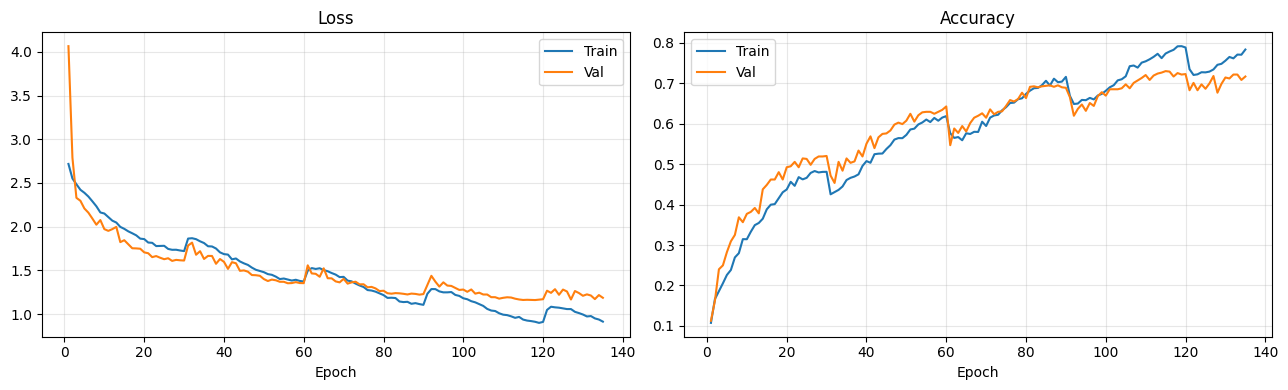

In [6]:
epochs_ran = len(train_acc_history)
x = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(x, train_loss_history, label='Train')
ax1.plot(x, val_loss_history,   label='Val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(x, train_acc_history, label='Train')
ax2.plot(x, val_acc_history,   label='Val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Load & Predict Functions (Submission Interface)

In [8]:
def load_model(weights_path='model.pth', num_classes=15):
    """Load the trained model from a .pth file."""
    m = TinyImageNetCNN(num_classes=num_classes)
    m.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    m.to(DEVICE)
    m.eval()
    return m


def predict(model, dataloader):
    """
    Run inference on a DataLoader and return predicted class indices.
    The dataloader should use val_transforms (no augmentation).
    """
    model.eval()
    all_preds = []
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
    return np.array(all_preds)


# verify everything works before submitting model.pth
loaded_model = load_model('model.pth', num_classes=NUM_CLASSES)
val_preds = predict(loaded_model, val_loader)

val_labels = val_dataset.labels
val_labels = np.array(val_dataset.labels)

acc = (val_preds == val_labels).mean()

print(f'model.pth accuracy on val set: {acc:.4f} ({acc*100:.2f}%)')

# also check predictions look sane, should see a spread across classes, not all one class
unique, counts = np.unique(val_preds, return_counts=True)
print('\nPrediction distribution:')
for cls, cnt in zip(unique, counts):
    print(f'  Class {cls:2d}: {cnt} predictions')


model.pth accuracy on val set: 0.7297 (72.97%)

Prediction distribution:
  Class  0: 51 predictions
  Class  1: 70 predictions
  Class  2: 49 predictions
  Class  3: 56 predictions
  Class  4: 52 predictions
  Class  5: 49 predictions
  Class  6: 56 predictions
  Class  7: 47 predictions
  Class  8: 67 predictions
  Class  9: 47 predictions
  Class 10: 62 predictions
  Class 11: 46 predictions
  Class 12: 48 predictions
  Class 13: 62 predictions
  Class 14: 63 predictions
